# Lab1: Agents Implementations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chebil/AI-course-book/blob/main/chapters/ch01_AgentLab.ipynb)


## What You'll Learn

- Build simple AI agents (reflex, model-based, goal-based)

**Prerequisites**: Basic Python knowledge

## Setup

Import required libraries for our implementations.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# For reproducibility
np.random.seed(42)
random.seed(42)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Simple Reflex Agent

A **reflex agent** makes decisions based only on the current percept (observation).

### Example: Thermostat Agent

The agent reads room temperature and decides to turn heater on/off.

In [14]:
class ThermostatAgent:
    """Simple reflex agent that controls room temperature."""
    
    def __init__(self, target_temp=22):
        self.target_temp = target_temp
    
    def perceive(self, room_temp):
        """Get current room temperature."""
        return room_temp
    
    def act(self, room_temp):
        """Decide action based on current temperature."""
        if room_temp < self.target_temp:
            return "HEAT_ON"
        else:
            return "HEAT_OFF"

# Test the agent
agent = ThermostatAgent(target_temp=22)

print("Testing Thermostat Agent:")
print(f"Room at 18°C → {agent.act(18)}")
print(f"Room at 25°C → {agent.act(25)}")
print(f"Room at 22°C → {agent.act(22)}")

Testing Thermostat Agent:
Room at 18°C → HEAT_ON
Room at 25°C → HEAT_OFF
Room at 22°C → HEAT_OFF


### Visualization: Agent Behavior Over Time

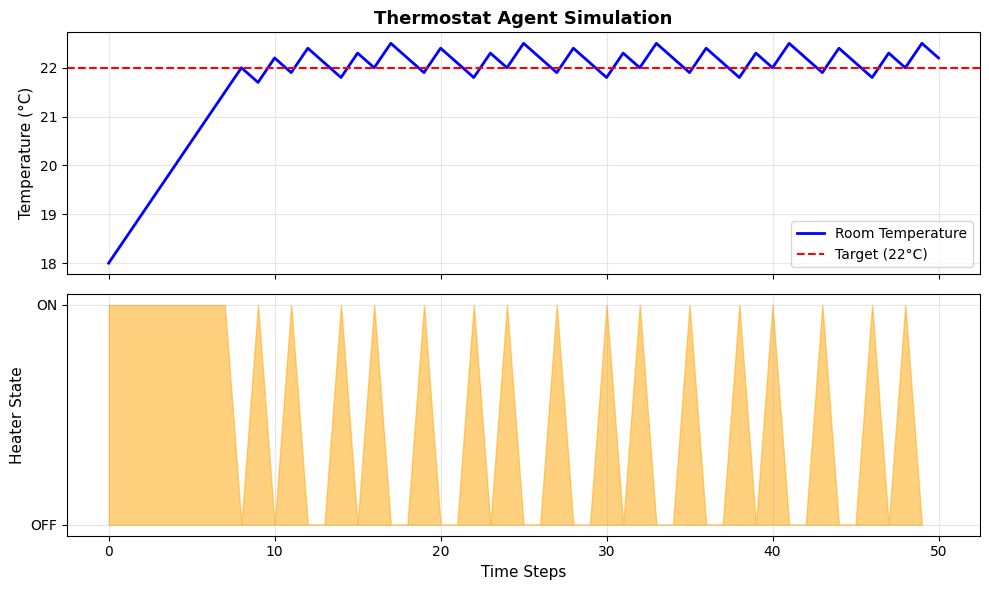

Final temperature: 22.2°C


In [15]:
# Simulate room temperature over time
def simulate_thermostat(initial_temp, target_temp, steps=50):
    """Simulate thermostat agent controlling room temperature."""
    agent = ThermostatAgent(target_temp)
    
    temps = [initial_temp]
    actions = []
    
    current_temp = initial_temp
    
    for _ in range(steps):
        action = agent.act(current_temp)
        actions.append(1 if action == "HEAT_ON" else 0)
        
        # Simple temperature dynamics
        if action == "HEAT_ON":
            current_temp += 0.5  # Heating
        else:
            current_temp -= 0.3  # Cooling
        
        temps.append(current_temp)
    
    return temps, actions

# Run simulation
temps, actions = simulate_thermostat(initial_temp=18, target_temp=22)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Temperature over time
ax1.plot(temps, 'b-', linewidth=2, label='Room Temperature')
ax1.axhline(y=22, color='r', linestyle='--', label='Target (22°C)')
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('Thermostat Agent Simulation', fontsize=13, fontweight='bold')

# Actions over time
ax2.fill_between(range(len(actions)), actions, alpha=0.5, color='orange')
ax2.set_xlabel('Time Steps', fontsize=11)
ax2.set_ylabel('Heater State', fontsize=11)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['OFF', 'ON'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final temperature: {temps[-1]:.1f}°C")

### Enhanced termostat agent with tolerance

To reduce frequent heater state switching, we can introduce a tolerance level.

In [17]:
import random
from typing import Dict, Any

class Environment:
    """Simple environment simulator"""
    def __init__(self, initial_temp: float = 20.0):
        self.temperature = initial_temp
        self.target_temp = 22.0
        
    def step(self, action: str) -> Dict[str, Any]:
        """Apply action and return new percept"""
        # Simulate temperature changes
        if action == 'heat':
            self.temperature += 0.5
        elif action == 'cool':
            self.temperature -= 0.5
        
        # Natural temperature drift
        self.temperature += random.uniform(-0.2, 0.2)
        
        return {
            'temperature': self.temperature,
            'target': self.target_temp
        }

class SimpleReflexAgent:
    """Agent that responds directly to percepts"""
    
    def __init__(self, tolerance: float = 1.0):
        self.tolerance = tolerance
        
    def perceive(self, percept: Dict[str, Any]) -> str:
        if(percept['temperature'] < percept['target'] - self.tolerance):
            return 'heat'
        elif(percept['temperature'] > percept['target'] + self.tolerance):
            return 'cool'
        else:
            return 'idle'

# Test your implementation
env = Environment(initial_temp=18.0)
agent = SimpleReflexAgent(tolerance=1.0)

print("Time\tTemp\tAction")
print("-" * 30)

for t in range(20):
    percept = {'temperature': env.temperature, 'target': env.target_temp}
    action = agent.perceive(percept)
    print(f"{t}\t{env.temperature:.1f}°C\t{action}")
    env.step(action)
    
print(f"\nFinal temperature: {env.temperature:.1f}°C")

Time	Temp	Action
------------------------------
0	18.0°C	heat
1	18.6°C	heat
2	18.9°C	heat
3	19.3°C	heat
4	19.7°C	heat
5	20.3°C	heat
6	20.8°C	heat
7	21.5°C	idle
8	21.3°C	idle
9	21.3°C	idle
10	21.1°C	idle
11	21.0°C	heat
12	21.5°C	idle
13	21.3°C	idle
14	21.2°C	idle
15	21.2°C	idle
16	21.3°C	idle
17	21.1°C	idle
18	21.2°C	idle
19	21.3°C	idle

Final temperature: 21.1°C


### visualization of enhanced agent behavior

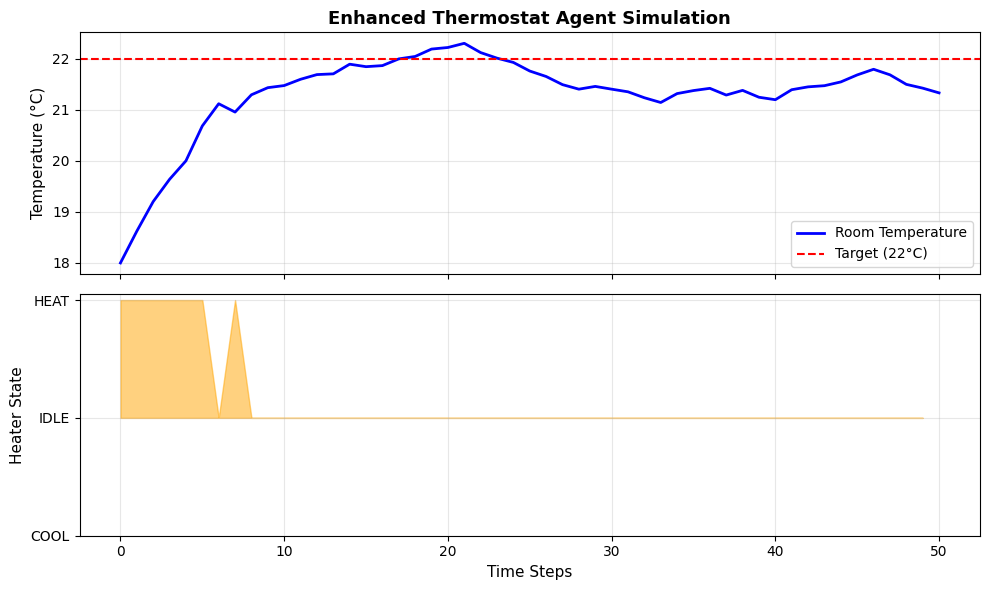

In [19]:
# Simulate enhanced agent behavior
def simulate_enhanced_agent(initial_temp, target_temp, tolerance, steps=50):
    """Simulate enhanced thermostat agent controlling room temperature."""
    agent = SimpleReflexAgent(tolerance)
    env = Environment(initial_temp)
    
    temps = [initial_temp]
    actions = []
    
    for _ in range(steps):
        percept = {'temperature': env.temperature, 'target': target_temp}
        action = agent.perceive(percept)
        actions.append(1 if action == "heat" else (0 if action == "idle" else -1))
        
        env.step(action)
        temps.append(env.temperature)
    
    return temps, actions
# Run simulation
temps, actions = simulate_enhanced_agent(initial_temp=18, target_temp=22, tolerance=1.0)
# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
# Temperature over time
ax1.plot(temps, 'b-', linewidth=2, label='Room Temperature')
ax1.axhline(y=22, color='r', linestyle='--', label='Target (22°C)')
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('Enhanced Thermostat Agent Simulation', fontsize=13, fontweight='bold')
# Actions over time
ax2.fill_between(range(len(actions)), actions, alpha=0.5, color='orange')
ax2.set_xlabel('Time Steps', fontsize=11)
ax2.set_ylabel('Heater State', fontsize=11)
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['COOL', 'IDLE', 'HEAT'])
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()  

## 2. Model-Based Agent

A **model-based agent** maintains an internal state to track the world.

### Example: Vacuum Cleaner Agent

The agent remembers which rooms it has cleaned.

In [16]:
class VacuumAgent:
    """Model-based vacuum cleaner agent."""
    
    def __init__(self, rooms):
        self.rooms = rooms  # List of room names
        self.current_room = rooms[0]
        # Internal model: track cleaned status
        self.cleaned = {room: False for room in rooms}
    
    def perceive(self, room_dirty):
        """Check if current room is dirty."""
        return room_dirty
    
    def act(self, room_dirty):
        """Decide action based on percept and internal state."""
        if room_dirty and not self.cleaned[self.current_room]:
            self.cleaned[self.current_room] = True
            return "CLEAN"
        elif all(self.cleaned.values()):
            return "DONE"
        else:
            # Move to next uncleaned room
            for room in self.rooms:
                if not self.cleaned[room]:
                    self.current_room = room
                    return f"MOVE_TO_{room}"
        return "IDLE"

# Test the agent
rooms = ['A', 'B', 'C']
agent = VacuumAgent(rooms)

# Simulate cleaning
print("Vacuum Agent Cleaning Process:")
room_status = {'A': True, 'B': True, 'C': True}  # All dirty

step = 1
while True:
    action = agent.act(room_status[agent.current_room])
    print(f"Step {step}: Room {agent.current_room} → {action}")
    
    if action == "DONE":
        break
    if action == "CLEAN":
        room_status[agent.current_room] = False
    
    step += 1
    if step > 10:  # Safety limit
        break

print(f"\nFinal state: {agent.cleaned}")

Vacuum Agent Cleaning Process:
Step 1: Room A → CLEAN
Step 2: Room B → MOVE_TO_B
Step 3: Room B → CLEAN
Step 4: Room C → MOVE_TO_C
Step 5: Room C → CLEAN
Step 6: Room C → DONE

Final state: {'A': True, 'B': True, 'C': True}
